In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
print(df.isnull().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicate rows")

print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True) * 100)

0 missing values
0 duplicate rows
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [ ]:
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print(const_cols)

df_clean = df.drop(columns=const_cols).copy()

['EmployeeCount', 'Over18', 'StandardHours']


In [ ]:
print(df[["MonthlyIncome", "DailyRate", "HourlyRate", "MonthlyRate"]].corr().round(2))

               MonthlyIncome  DailyRate  HourlyRate  MonthlyRate
MonthlyIncome           1.00       0.01       -0.02         0.03
DailyRate               0.01       1.00        0.02        -0.03
HourlyRate             -0.02       0.02        1.00        -0.02
MonthlyRate             0.03      -0.03       -0.02         1.00


In [ ]:
df_clean = df_clean.drop(columns=["DailyRate", "HourlyRate", "MonthlyRate"])

In [ ]:
df_clean["Education"] = df_clean["Education"].map({
    1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"})

rating = {1: "Low", 2: "Medium", 3: "High", 4: "Very High"}
for col in ["JobSatisfaction", "EnvironmentSatisfaction",
            "RelationshipSatisfaction", "JobInvolvement"]:
    df_clean[col] = df_clean[col].map(rating)

df_clean["WorkLifeBalance"] = df_clean["WorkLifeBalance"].map({
    1: "Bad", 2: "Good", 3: "Better", 4: "Best"})

In [ ]:
df_clean["AttritionFlag"] = (df_clean["Attrition"] == "Yes").astype(int)

df_clean["AgeGroup"] = pd.cut(df_clean["Age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"])

df_clean["TenureGroup"] = pd.cut(df_clean["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 50],
    labels=["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"])

df_clean["IncomeBand"] = pd.qcut(df_clean["MonthlyIncome"], 4,
    labels=["Low", "Medium", "High", "Very High"])

In [ ]:
print(df_clean.shape)
print(df_clean[["AgeGroup", "TenureGroup", "IncomeBand"]].isnull().sum())
df_clean.head()

df_clean.to_csv("hr_clean.csv", index=False)
files.download("hr_clean.csv")

(1470, 33)
AgeGroup       0
TenureGroup    0
IncomeBand     0
dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

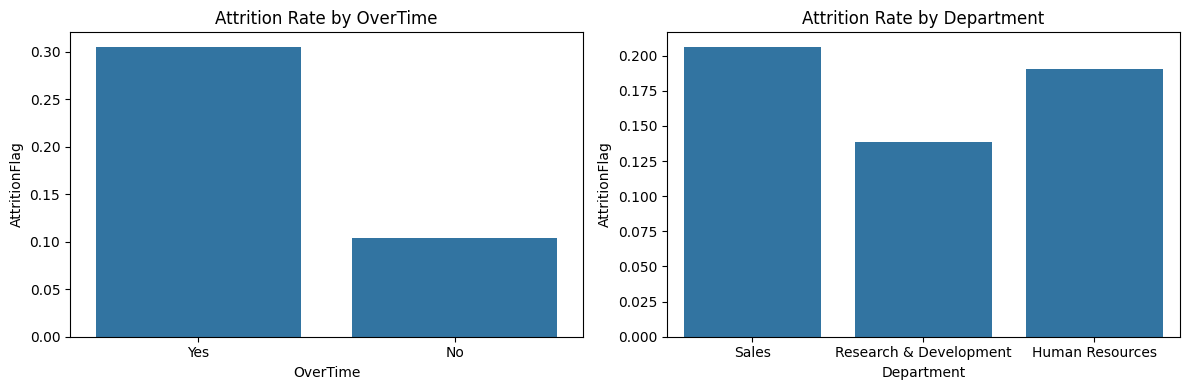

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df_clean, x="OverTime", y="AttritionFlag", ax=ax[0], errorbar=None)
ax[0].set_title("Attrition Rate by OverTime")
sns.barplot(data=df_clean, x="Department", y="AttritionFlag", ax=ax[1], errorbar=None)
ax[1].set_title("Attrition Rate by Department")
plt.tight_layout(); plt.savefig("eda_1_overtime_dept.png", dpi=150); plt.show()

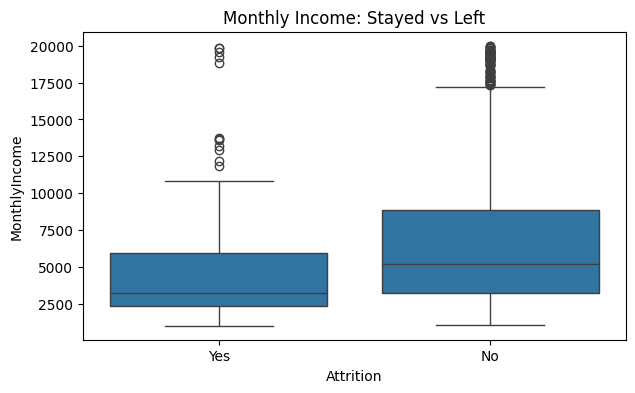

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income: Stayed vs Left")
plt.savefig("eda_2_income.png", dpi=150); plt.show()

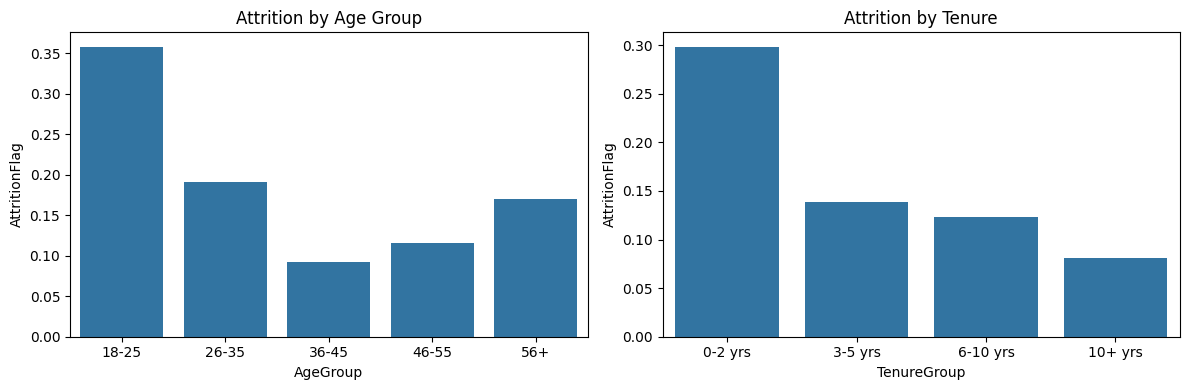

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df_clean, x="AgeGroup", y="AttritionFlag", ax=ax[0], errorbar=None)
sns.barplot(data=df_clean, x="TenureGroup", y="AttritionFlag", ax=ax[1], errorbar=None)
ax[0].set_title("Attrition by Age Group"); ax[1].set_title("Attrition by Tenure")
plt.tight_layout(); plt.savefig("eda_3_age_tenure.png", dpi=150); plt.show()

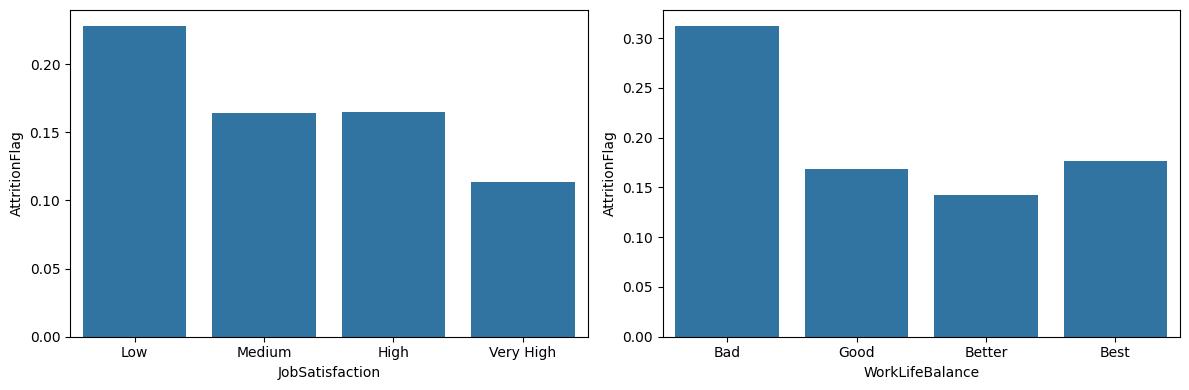

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
order_s = ["Low", "Medium", "High", "Very High"]
sns.barplot(data=df_clean, x="JobSatisfaction", y="AttritionFlag", order=order_s, ax=ax[0], errorbar=None)
sns.barplot(data=df_clean, x="WorkLifeBalance", y="AttritionFlag",
            order=["Bad", "Good", "Better", "Best"], ax=ax[1], errorbar=None)
plt.tight_layout(); plt.savefig("eda_4_satisfaction.png", dpi=150); plt.show()

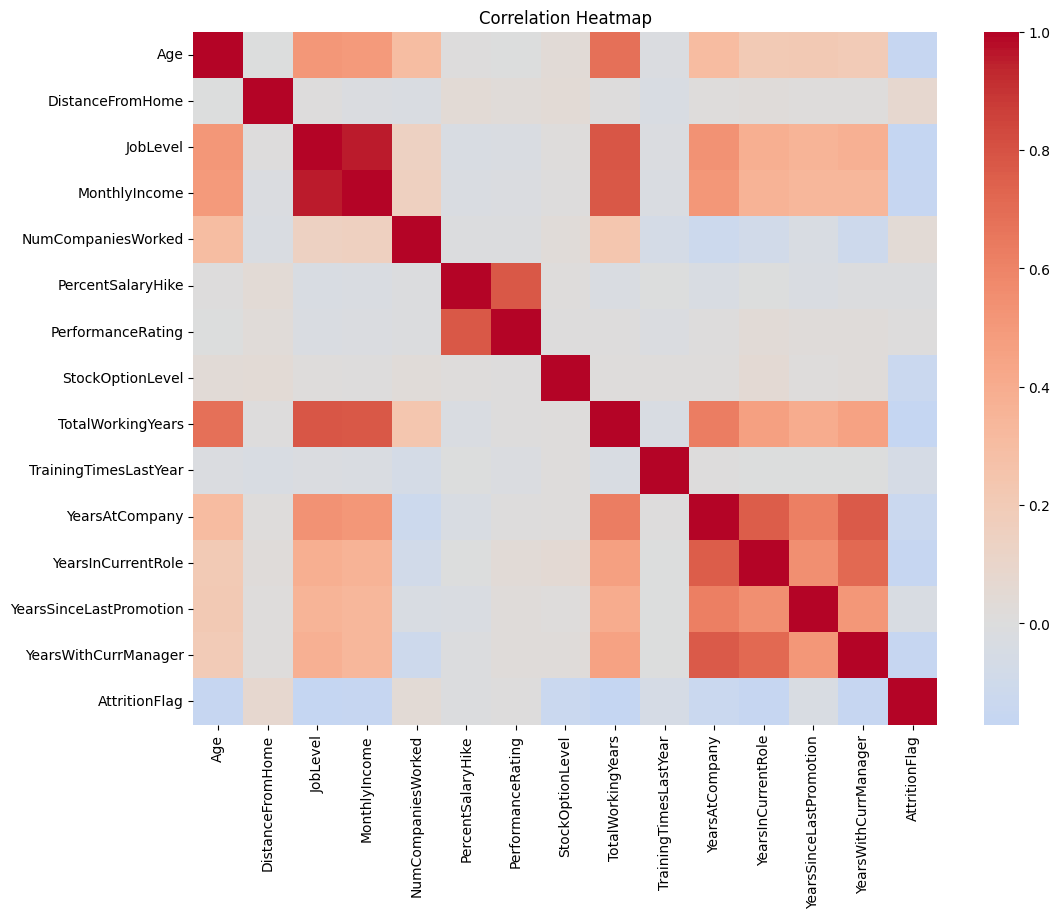

TotalWorkingYears         -0.17
JobLevel                  -0.17
YearsInCurrentRole        -0.16
MonthlyIncome             -0.16
Age                       -0.16
YearsWithCurrManager      -0.16
StockOptionLevel          -0.14
YearsAtCompany            -0.13
TrainingTimesLastYear     -0.06
YearsSinceLastPromotion   -0.03
PercentSalaryHike         -0.01
PerformanceRating          0.00
NumCompaniesWorked         0.04
DistanceFromHome           0.08
AttritionFlag              1.00
Name: AttritionFlag, dtype: float64


In [ ]:
num = df_clean.select_dtypes("number").drop(columns=["EmployeeNumber"])
plt.figure(figsize=(12, 9))
sns.heatmap(num.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.savefig("eda_5_corr.png", dpi=150, bbox_inches="tight"); plt.show()

print(num.corr()["AttritionFlag"].sort_values().round(2))